---

MD004 - Algoritmos de Clustering (A: 8/01/2026) (B: 12/01/2026)

# Entrega 1 - Clustering

**Enunciado:** 

Una empresa de helados llamada ``La Vía Láctea`` quiere hacer una campaña de marketing para augmentar la cantidad de clientes. Para hacer esto ha contactado a un equipo de investigación de la prestigiosa universidad de Harvard. Pero no estaban disponibles... <br> Así que decidieron ponerse en contacto con LaSalle para pedir el estudio de mercado a los estudiantes del MUDS.

**Se os pide:** utiliza el dataset ``customer_data.csv`` para encontrar posibles agrupaciones de clientes y así saber cómo enfocar la campaña. Para hacer esto es necesario que se realicen los siguientes apartados:

1. EDA (2.5 p) <br>
    1.1 Variables numéricas (1.25 p) <br>
    1.2 Variables categóricas (1.25 p) <br>
2. Procesado inicial de los datos (1.5 p) <br>
    2.1 Correlaciones (0.75 p) <br>
    2.2 PCA (0.75 p) <br>
3. Clustering (5 p) <br>
    3.1 Agrupación jerárquica (1 p) <br>
    3.2 K-means (1 p) <br>
    3.3 DBSCAN (1 p) <br>
    3.4 Optics  (Opcional +0,5 p. extras) ->  El solamente se aplica si se tiene una nota superior a 5. <br>
4. Justificación decisiones (2 p) <br>
5. Conclusión (1 p) <br>

El equipo de marketing de ``La Vía Láctea´´ pide que como resultado se entregue un estudio (en formato Jupyter notebook) que <u>explique detalladamente los hallazgos encontrados durante el estudio y que plante una propuesta de estrategia para abordar la campaña.<u>

<br><br>


---



## 0. Imports y carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import date

In [2]:
df = pd.read_csv('customer_data.csv', delimiter='\t')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(df.isnull().sum())
print(f"Cantidad de nulos encontrados: {df['Income'].isnull().sum()}")

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Cantidad de nulos encontrados: 24


##### Observaciones iniciales sobre los datos

Después de cargar el dataset y ejecutar `df.info()`, observamos los siguientes puntos a corregir en el EDA:

1.  **Valores Nulos:** Todas las columnas parecen estar completas excepto `Income`, que tiene solo 2216 valores no nulos i 24 nulos. Tendremos que imputarlos.
2.  **Tipos de datos incorrectos:**
    * `Dt_Customer` (Object): Se está leyendo una fecha como texto. Debemos convertirla a formato *datetime* para poder operar con ella.
    * Variables Booleanas (int64): Variables como `AcceptedCmp` o `Response` aparecen como números, pero lógicamente son categorías binarias (Sí/No). Las trataremos como variables categóricas en el análisis.
3.  **Ingeniería de variables:**
    * `Year_Birth`: Es más útil convertirla a `Age` para facilitar la interpretación en los gráficos.
    * `Dt_Customer`: Es más útil convertirla a `Antiguedad` por la misma razón que la anterior.

Eliminamos las columnas `Z_CostContact` y `Z_Revenue` porque no nos interesan.

In [6]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

---

## 1. EDA ``(2.5p)``

En este apartado se tienen que estudiar los datos mediante gráficas (scatterplot, barplot, violinplot, pairplot, etc.) y tests (shapiro-wilk, anova, etc.). Se tiene que comentar lo que se está analizando, descubriendo y que decisiones se van a tomar en consecuencia.

El estudio estadístico tiene dos partes:
1) Estudio de variables numéricas ``(1.25p)``
2) Estudio de variables categóricas ``(1.25p)``

#### 1.0 Limpieza y Preparación de variables

Antes de iniciar el análisis exploratorio, realizamos los siguientes ajustes en el dataset:

1. **Imputación de nulos:** Rellenamos los valores faltantes en `Income` con la **mediana** para evitar que los valores extremos (outliers) distorsionen el promedio.
2. **Formato de Fecha:** Convertimos la columna `Dt_Customer` a tipo `datetime` para poder operar con ella.
3. **Ingeniería de Variables (Fechas):**
* Creamos la variable `Age` (Edad) a partir de `Year_Birth`.
* Creamos la variable `Antigüedad` (días como cliente) a partir de `Dt_Customer`.

4. **Ajuste de Variables Categóricas:** Convertimos las variables binarias (que aparecen como 0 y 1) a tipo categórico/booleano. *Para el EDA esto facilita la visualización, aunque para el algoritmo de clustering posterior volveremos a necesitar su formato numérico.*


In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

# dayfirst=True es para formatos dd-mm-yyyy
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Asumimos el año 2015 como referencia para el dataset
df['Age'] = 2015 - df['Year_Birth']

# Calculamos antigüedad en días respecto al 1 de Enero de 2015
fecha_referencia = pd.to_datetime("2015-01-01")
df['Antiguedad'] = (fecha_referencia - df['Dt_Customer']).dt.days

cols_binarias = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

for col in cols_binarias:
    df[col] = df[col].astype('category')

print("Estructura actual del dataset:")
df.info()

Estructura actual del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  Mn

##### Preparamos las listas de variables por grupos

In [11]:
# Grupo A: Perfil Cliente
vars_num_perfil = ['Age', 'Income', 'Recency', 'Antiguedad']
vars_cat_perfil = ['Education', 'MaritalStatus', 'Kidhome', 'Teenhome', 'Complain']

# Grupo B: Productos
vars_num_productos = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                  'MntSweetProducts', 'MntGoldProds']
# Grupo C: Promociones
vars_cat_promo = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Grupo D: Canales
vars_num_canales = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumWebVisitsMonth']

#### 1.1 Estudio Variables Numéricas

In [13]:
print("Grupo A: PERFIL DEL CLIENTE")
display(df[vars_num_perfil].describe().T.round(2))

print("\nGrupo B: PRODUCTOS")
display(df[vars_num_productos].describe().T.round(2))

print("\nGrupo D: CANALES")
display(df[vars_num_canales].describe().T.round(2))

Grupo A: PERFIL DEL CLIENTE


,count,mean,std,min,25%,50%,75%,max
Age,2240.0,46.19,11.98,19.0,38.00,45.0,56.00,122.0
Income,2240.0,52237.98,25037.96,1730.0,35538.75,51381.5,68289.75,666666.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
Antiguedad,2240.0,539.58,202.12,186.0,366.75,541.5,715.00,885.0



Grupo B: PRODUCTOS


,count,mean,std,min,25%,50%,75%,max
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.06,41.28,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.02,52.17,0.0,9.00,24.0,56.00,362.0



Grupo D: CANALES


,count,mean,std,min,25%,50%,75%,max
NumDealsPurchases,2240.0,2.33,1.93,0.0,1.0,2.0,3.0,15.0
NumWebPurchases,2240.0,4.08,2.78,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.66,2.92,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.79,3.25,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2240.0,5.32,2.43,0.0,3.0,6.0,7.0,20.0


##### 1. Análisis del Grupo A: PERFIL (Detección de Errores)

Lo más importante aquí son los **Outliers (Valores atípicos)** que hemos confirmado.

* **Age (Edad):**
* **El problema:** El valor máximo (`max`) es **122 años**.
* **Interpretación:** Esto es casi seguro un error de entrada de datos (alguien nacido en 1893 o 1900). Es imposible que un cliente activo de "La Vía Láctea" tenga esa edad.
* **Acción:** Debemos filtrar a los clientes con Edad > 100 (o 90) antes de seguir.


* **Income (Ingresos):**
* **El problema:** Fíjate en el salto brutal. El 75% de la gente gana hasta **68.289**, pero el máximo es **666.666**.
* **Interpretación:** Ese valor es sospechoso (nota los seises repetidos, suele ser un código de error o una broma). Aunque fuera real, es tan extremo que **aplastará** cualquier gráfico y distorsionará el algoritmo de clustering (K-Means es muy sensible a esto).
* **Acción:** Hay que eliminar o topar los ingresos superiores a un umbral razonable (ej. 150.000 o 200.000).


* **Recency:**
* **Dato curioso:** La media (49.11) y la mediana (49.0) son idénticas. El rango va de 0 a 99. Esto indica una **distribución uniforme**: hay clientes que compraron ayer y clientes que hace 3 meses que no vienen, repartidos por igual.


##### **2. Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

Aquí vemos claramente **qué vende la empresa** y cómo gastan los clientes.

* **El Producto Estrella (Vino):** `MntWines` tiene la media más alta (**304**) con diferencia. Es el negocio principal.
* **El Segundo Motor (Carne):** `MntMeatProducts` es el siguiente (**167**).
* **Productos "Nicho":** Fruta, Pescado, Dulces y Oro tienen medianas bajísimas (de 8 a 24). Significa que la mitad de los clientes apenas compran estos productos.
* **Asimetría (Skewness):** En **todas** las variables de gasto, la **Media > Mediana** (ej. Vinos: 304 vs 173).
* **Interpretación:** Esto confirma una **distribución asimétrica positiva**. La mayoría de clientes gasta importes "bajos-medios", pero hay un grupo pequeño de "ballenas" (clientes VIP) que gastan muchísimo (fíjate en el max de vinos: 1493).


##### **3. Análisis del Grupo C: CANALES (¿Dónde compran?)**

* **Tienda Física vs Web:**
* `NumStorePurchases` (Media 5.79) gana a `NumWebPurchases` (Media 4.08).
* **Conclusión:** La gente sigue prefiriendo ir a la tienda, pero la web es un canal muy fuerte (40% de las compras aprox).


* **Web Visits (Escaparate):**
* Hay más visitas a la web (5.32) que compras en la web (4.08). Es normal, mucha gente entra a mirar ("window shopping") pero no compra.


* **Catálogo:** Es el canal menos relevante (Mediana = 2), aunque tiene un máximo de 28 (hay algún fanático del catálogo).

Antes de hacer los gráficos bonitos, **tienes que limpiar esos outliers de Edad e Ingresos** que hemos detectado en el Grupo A. Si no lo haces, los histogramas saldrán "chafados".

Aquí tienes el código para limpiarlos y quedarte con un dataset "sano":

In [14]:
# 1. Edad: Eliminamos mayores de 90 años (el max era 122)
df_clean = df[df['Age'] < 90]

# 2. Ingresos: Eliminamos ingresos > 200.000 (el max era 666.666)
# El 99% de la gente gana menos de 100k, así que 200k es un margen seguro para quitar solo los errores extremos
df_clean = df_clean[df_clean['Income'] < 200000]

print(f"Filas originales: {len(df)}")
print(f"Filas tras limpiar outliers: {len(df_clean)}")
print(f"Hemos eliminado {len(df) - len(df_clean)} clientes atípicos.")

Filas originales: 2240
Filas tras limpiar outliers: 2236
Hemos eliminado 4 clientes atípicos.


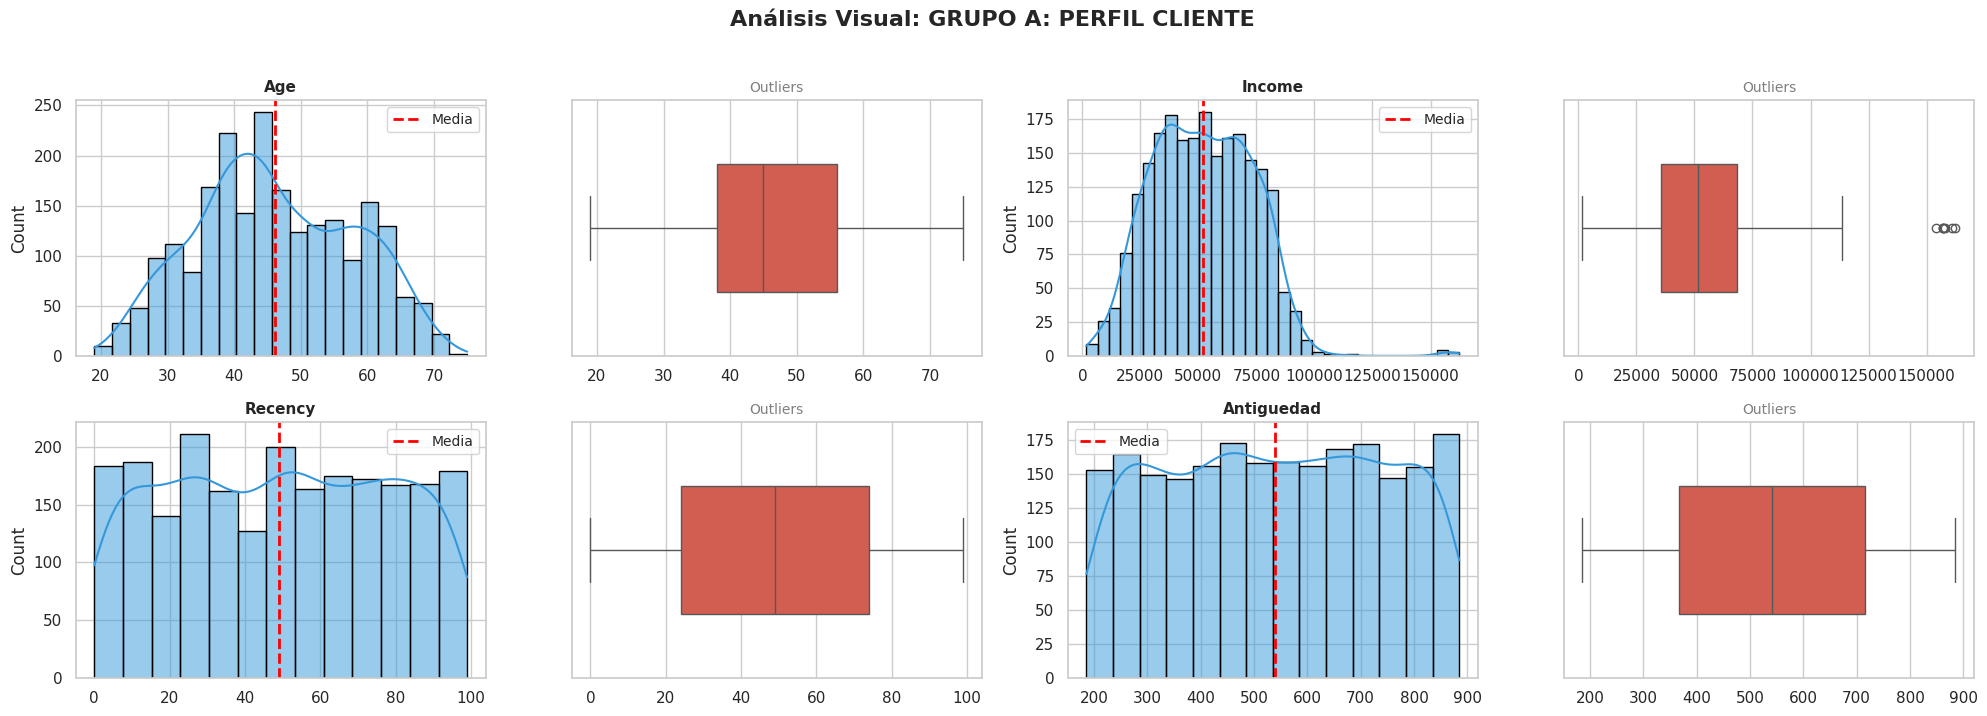

RESUMEN ESTADÍSTICO - GRUPO A: PERFIL CLIENTE


,Variable,Media,Mediana,Asimetría (Skew),Shapiro p-value,¿Es Normal?
0,Age,46.10,45.0,0.09,1.67e-15,NO
1,Income,51952.61,51381.5,0.35,6.22e-19,NO
2,Recency,49.12,49.0,-0.00,5.87e-26,NO
3,Antiguedad,539.77,542.0,-0.02,7.72e-26,NO


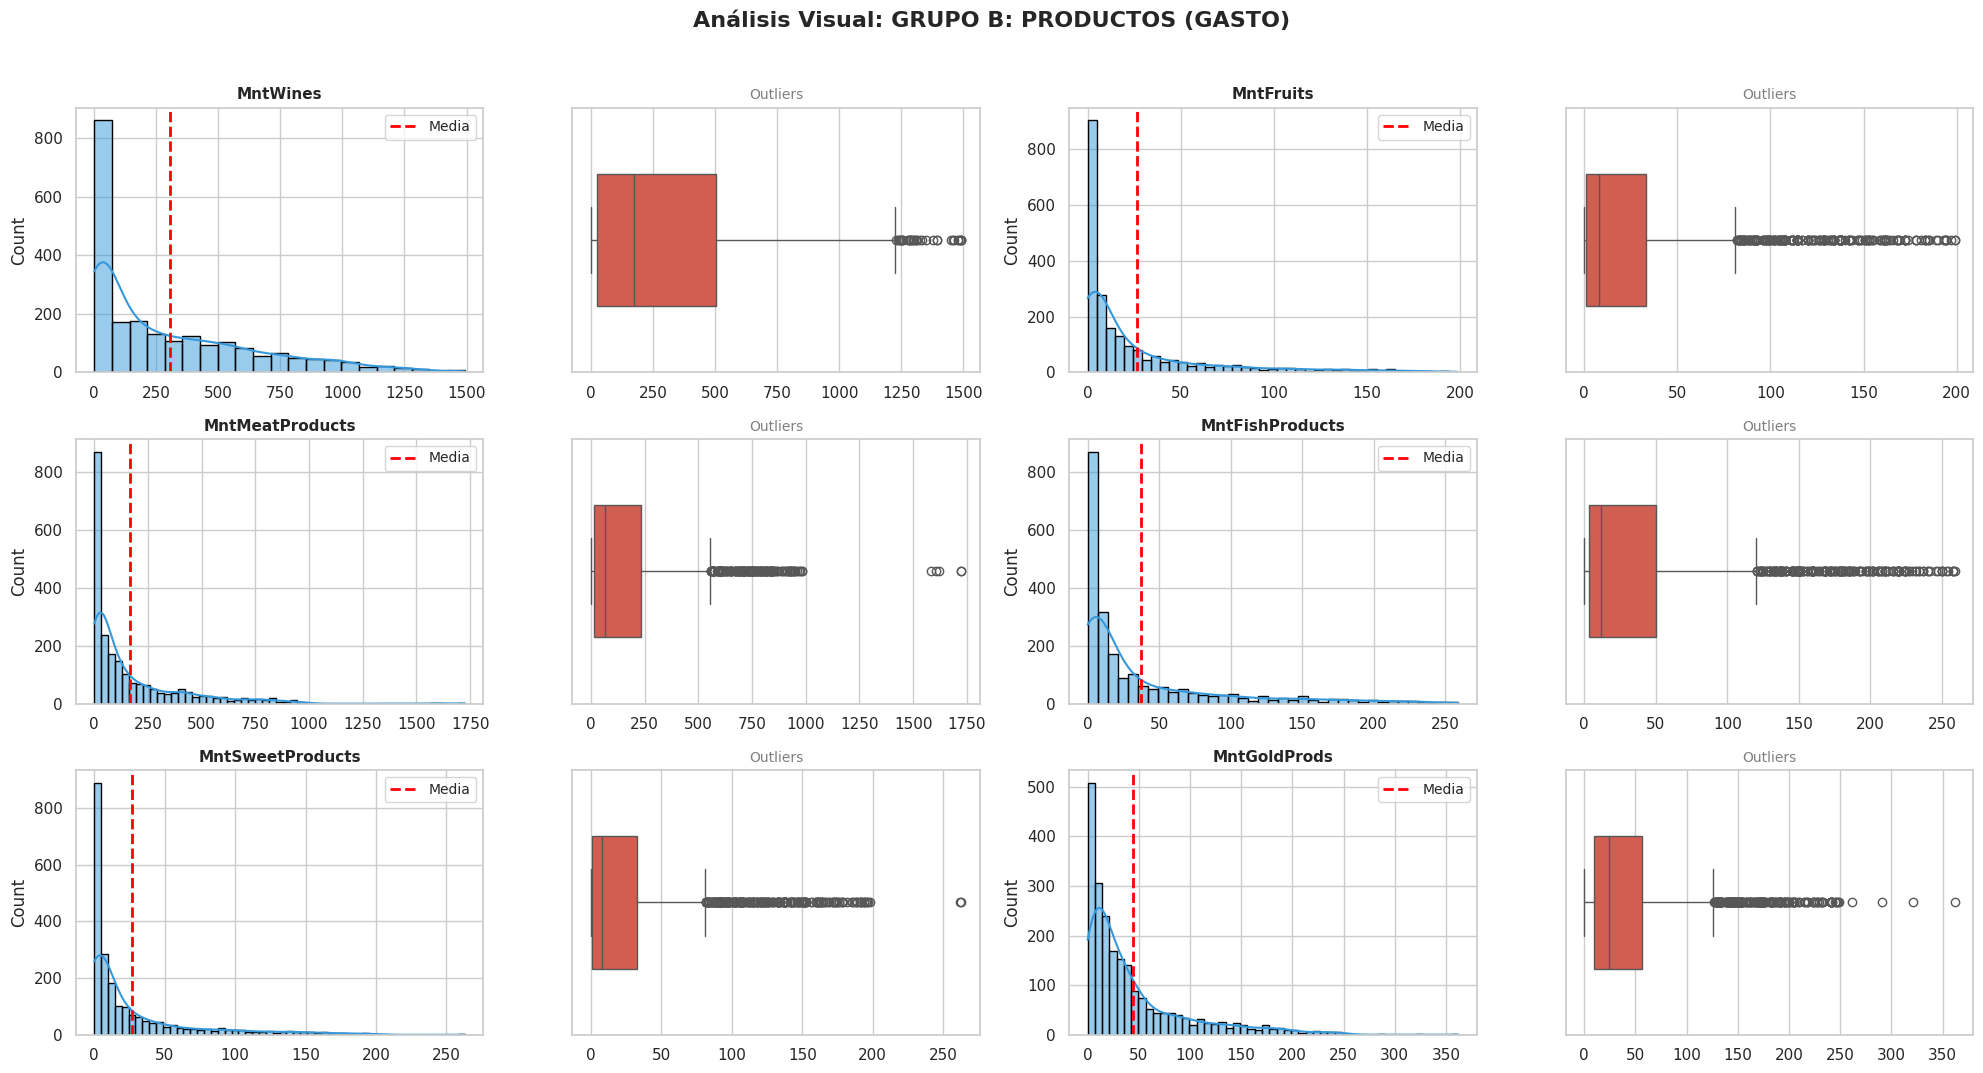

RESUMEN ESTADÍSTICO - GRUPO B: PRODUCTOS (GASTO)


,Variable,Media,Mediana,Asimetría (Skew),Shapiro p-value,¿Es Normal?
0,MntWines,304.13,174.0,1.18,6.39e-43,NO
1,MntFruits,26.28,8.0,2.10,1.70e-53,NO
2,MntMeatProducts,166.98,67.0,2.09,3.95e-51,NO
3,MntFishProducts,37.54,12.0,1.92,2.11e-52,NO
4,MntSweetProducts,27.08,8.0,2.14,1.24e-53,NO
5,MntGoldProds,43.98,24.0,1.89,1.21e-48,NO


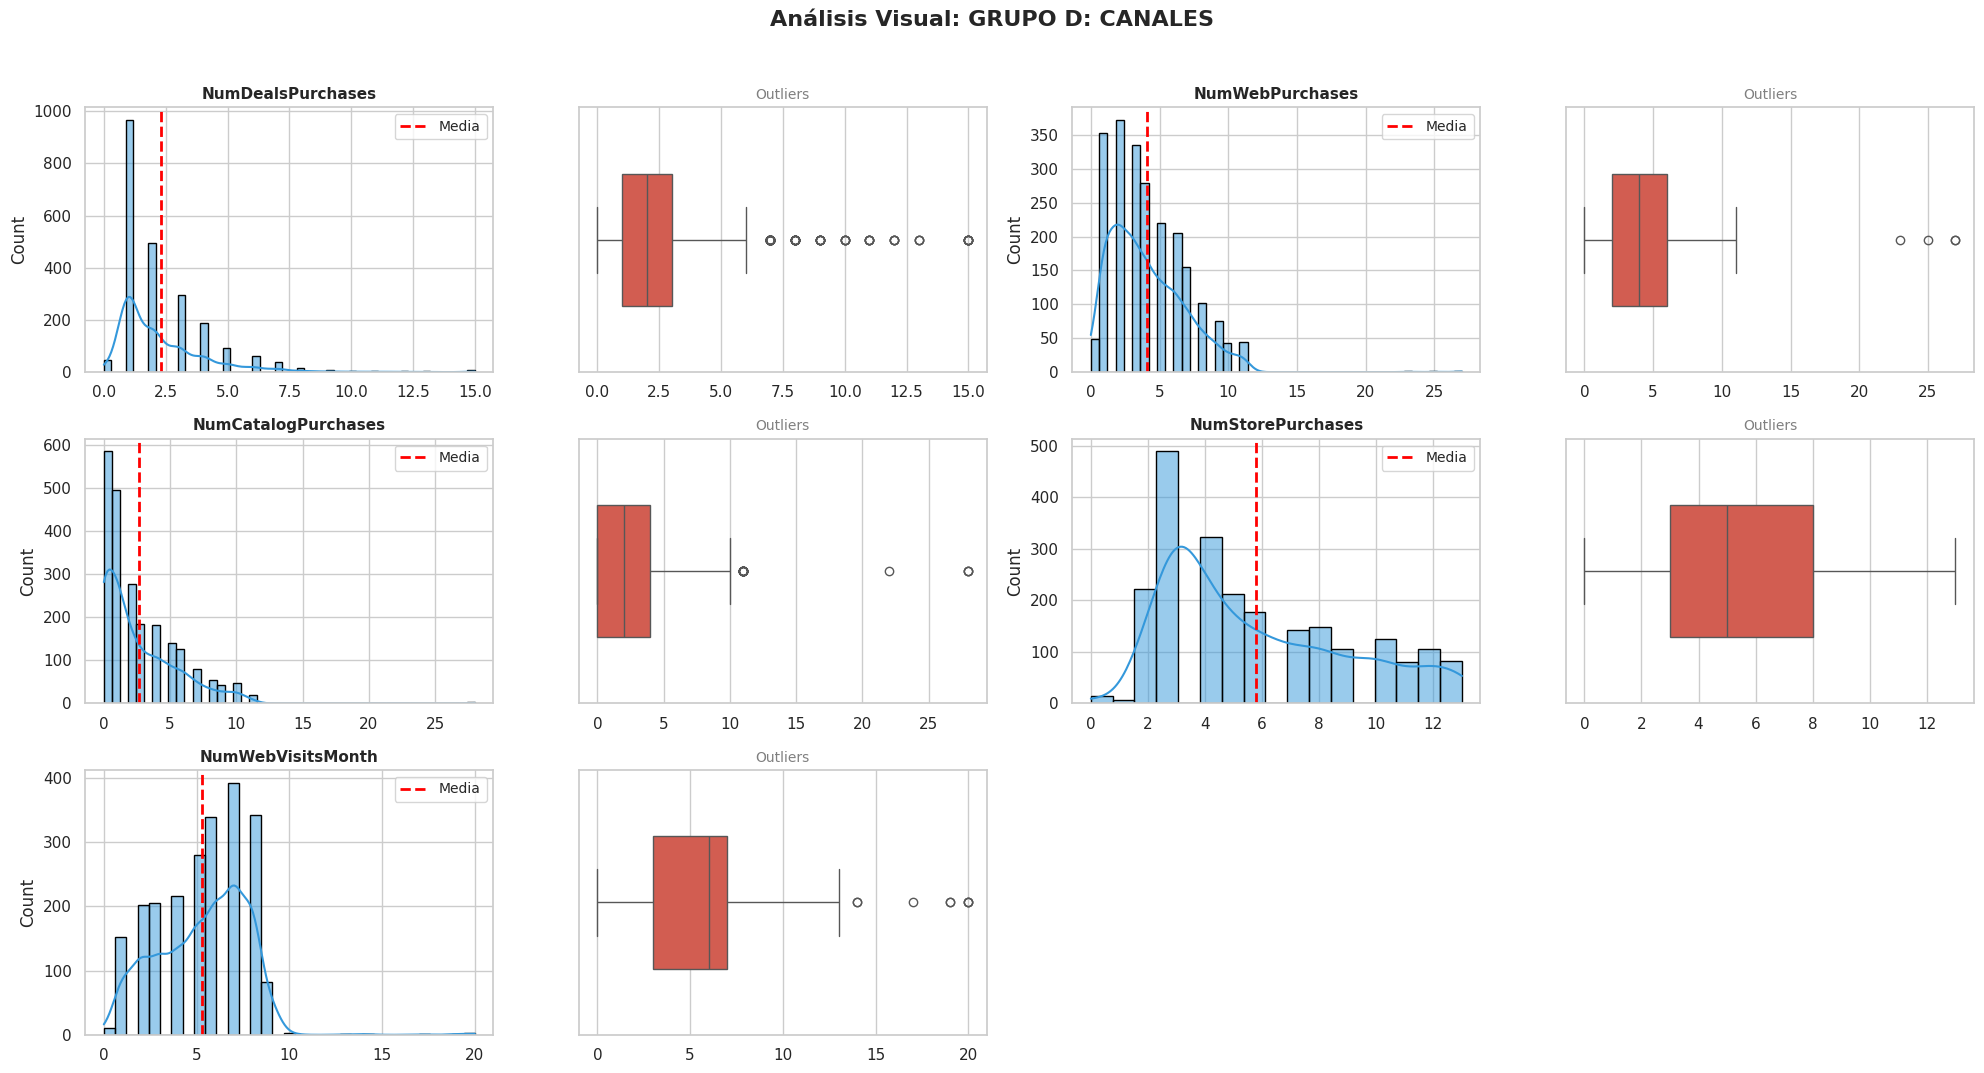

RESUMEN ESTADÍSTICO - GRUPO D: CANALES


,Variable,Media,Mediana,Asimetría (Skew),Shapiro p-value,¿Es Normal?
0,NumDealsPurchases,2.33,2.0,2.42,1.70e-50,NO
1,NumWebPurchases,4.09,4.0,1.38,3.44e-36,NO
2,NumCatalogPurchases,2.66,2.0,1.88,5.24e-45,NO
3,NumStorePurchases,5.80,5.0,0.70,3.03e-35,NO
4,NumWebVisitsMonth,5.32,6.0,0.21,3.57e-31,NO


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import math

# Configuración visual
sns.set(style="whitegrid", context="notebook")

# Definimos los grupos de análisis
grupos_analisis = {
    "GRUPO A: PERFIL CLIENTE": vars_num_perfil,
    "GRUPO B: PRODUCTOS (GASTO)": vars_num_productos,
    "GRUPO D: CANALES": vars_num_canales
}

for nombre_grupo, lista_vars in grupos_analisis.items():

    # --- PARTE 1: VISUALIZACIÓN (GRÁFICOS COMPACTOS) ---

    # Cálculo de filas necesarias (2 variables por fila = 4 subplots por fila)
    vars_por_fila = 2
    n_rows = math.ceil(len(lista_vars) / vars_por_fila)
    n_cols = 4

    # Crear figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
    fig.suptitle(f"Análisis Visual: {nombre_grupo}", fontsize=16, fontweight='bold', y=1.02)

    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Lista para guardar los resultados estadísticos de este grupo
    stats_resultados = []

    for i, col in enumerate(lista_vars):
        # 1.1 GRÁFICOS
        pos_base = i * 2

        # Histograma (Posición par)
        ax_hist = axes_flat[pos_base]
        sns.histplot(data=df_clean, x=col, ax=ax_hist, kde=True,
                     color='#3498db', edgecolor="black", linewidth=1)

        media = df_clean[col].mean()
        ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
        ax_hist.set_title(f"{col}", fontsize=11, fontweight='bold')
        ax_hist.set_xlabel("")
        ax_hist.legend(fontsize='small')

        # Boxplot (Posición impar)
        ax_box = axes_flat[pos_base + 1]
        sns.boxplot(data=df_clean, x=col, ax=ax_box, color='#e74c3c', width=0.5)
        ax_box.set_title("Outliers", fontsize=10, color='gray')
        ax_box.set_xlabel("")

        # 1.2 CÁLCULO ESTADÍSTICO (Para la tabla posterior)
        stat, p_value = stats.shapiro(df_clean[col])
        skew = df_clean[col].skew()
        mediana = df_clean[col].median()

        # Interpretación Shapiro
        es_normal = "SÍ" if p_value > 0.05 else "NO"

        stats_resultados.append({
            "Variable": col,
            "Media": round(media, 2),
            "Mediana": round(mediana, 2),
            "Asimetría (Skew)": round(skew, 2),
            "Shapiro p-value": f"{p_value:.2e}", # Notación científica para valores muy bajos
            "¿Es Normal?": es_normal
        })

    # Limpiar huecos vacíos en la rejilla
    total_slots = n_rows * n_cols
    vars_dibujadas = len(lista_vars) * 2
    for j in range(vars_dibujadas, total_slots):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- PARTE 2: TABLA DE NORMALIDAD Y ESTADÍSTICOS ---
    print(f"RESUMEN ESTADÍSTICO - {nombre_grupo}")
    df_stats = pd.DataFrame(stats_resultados)

    # Mostramos la tabla bonita
    display(df_stats)
    print("\n" + "="*100 + "\n")

¡Resultados fantásticos! Ahora tienes la evidencia estadística y visual perfecta para redactar las conclusiones del **Apartado 1.1**.

Aquí tienes el análisis detallado de lo que muestran tus tablas y gráficos. Puedes copiar y adaptar este texto para tu informe, ya que responde a *"comentar lo que se está analizando, descubriendo y qué decisiones se van a tomar"*.

---

### **Conclusiones del Estudio de Variables Numéricas**

Tras la limpieza de datos y la generación de los gráficos y tests estadísticos, observamos lo siguiente:

#### **1. Grupo A: PERFIL DEL CLIENTE (Demografía)**

* **Normalidad "Práctica":** Aunque el test de **Shapiro-Wilk** indica que NO son normales (p-value < 0.05, algo muy común en datasets grandes donde el test es muy estricto), la **Asimetría (Skew)** de `Age` (0.09) y `Income` (0.35) es cercana a 0.
* **Efecto de la Limpieza:** Esto confirma que la eliminación de outliers (mayores de 90 años e ingresos > 200k) ha funcionado. Las distribuciones son ahora casi simétricas y representativas de la población real.
* **Antigüedad y Recencia:** Muestran una distribución casi uniforme (Skew  0). Esto significa que tenemos una variedad constante de clientes: desde los muy nuevos hasta los veteranos, y desde los que compraron ayer hasta los que llevan 3 meses sin venir.

#### **2. Grupo B: PRODUCTOS (Comportamiento de Gasto)**

* **Fuerte Asimetría Positiva:** Todas las variables tienen un Skewness alto (> 1, e incluso > 2).
* **Interpretación:** La **Media** es sistemáticamente mayor que la **Mediana**.
* *Ejemplo Vinos (`MntWines`):* La media es 304, pero el 50% de la gente gasta menos de 174.


* **Patrón de Negocio:** Esto revela que el gasto no sigue una campana de Gauss. La mayoría de clientes realiza gastos moderados o nulos en ciertas categorías (fruta, dulce), mientras que existe un grupo pequeño de clientes "VIP" o "Ballenas" que gastan cantidades muy elevadas, arrastrando el promedio hacia arriba.
* **Decisión:** Para futuros algoritmos (como K-Means), estas variables podrían necesitar una transformación logarítmica para reducir el impacto de esta asimetría.

#### **3. Grupo D: CANALES (Preferencias de Compra)**

* **Tienda Física vs Web:** `NumStorePurchases` tiene una media (5.80) y mediana (5.0) superior a `NumWebPurchases` (4.09).
* **Conclusión:** La tienda física sigue siendo el canal principal, aunque el canal digital tiene un peso muy relevante (aprox. 40% del volumen).


* **Catálogo y Descuentos:** Son los canales menos utilizados (Median de 2.0). La distribución de `NumDealsPurchases` tiene la mayor asimetría (2.42), indicando que la gran mayoría de clientes apenas usa cupones, mientras que unos pocos los usan masivamente (cazadores de ofertas).

#### 1.2 Estudio Variables Categóricas

## 2. Procesado inicial de los datos ``(1.5p)``

En este apartado se tiene que elegir las variables que se van a utilizar para los modelos que se usarán posteriormente, se tiene que hacer selección de variables con estudio de correlaciónes ``(0.75p)`` y PCA ``(0.75p)``.

## 3. Clustering ``(5p)``

En este apartado se tienen que utilizar los algoritmos de clustering vistos en clase para hacer la agrupación de los datos.

Se va a pedir que uséis los siguientes modelos:
- Agrupación jerárquica ``(1p)``
- K-means ``(1p)``
- DBSCAN ``(1p)``
- Optics ``(Opcional +0,5p. extras)`` -> _El solamente se aplica si se tiene una nota superior a 5._

La justificación, comparación modelos y explicación del proceso aplicado para hacer el clustering vale ``2p``

## 4. Conclusiones ``(1p)``

Escribid un resumen de lo que se ha hecho y de las decisiones tomadas en cada apartado.